# 05 · The Pricing Team — IP Agent, PMI Agent, and a Router
### ABC Health | 9th IAI Capacity Building Seminar in Health and Care Insurance

**Used in:** Session 2, Part 2 (Scaling Up — Multi-Agent Patterns). **You will:** wire up two specialist pricing agents — one for Income Protection, one for PMI — under a single `agno.team.Team` that routes each query to whichever agent fits, or answers directly from a small policy-document knowledge base when the question is about assumptions rather than a specific quote.

**This notebook does no data generation.** Both products' data were generated once, in `data_notebook.ipynb`, and pickled to `ip_pricing_artifacts.pkl` / `pmi_pricing_artifacts.pkl`. If those files aren't sitting next to this notebook, run the data notebook first (or ask your trainer for the two files).

**Architecture:**
- **IP agent** — the real Tool 1/2/3 pricing tools from notebook 04, reused verbatim (not re-derived). Answers with a premium quote, a plain-English explanation, and 3 charts.
- **PMI agent** — a new, simpler frequency × severity = pure premium tool, calibrated to this seminar's canonical PMI figures. **No expense or profit loading** — pure risk premium only.
- **Team (route mode)** — the leader inspects each query and either routes it to the matching specialist agent, or answers directly using its own retrieval tool over two policy-assumption documents (`ip_policy_assumptions.md`, `pmi_policy_assumptions.md`).

Prereq: `GOOGLE_API_KEY` in Colab Secrets (as in notebooks 01/03/04).

## 0. Setup

In [1]:
%pip install -q "agno==3.0.0" "google-genai==2.19.0" "scikit-learn==1.9.0" "pyarrow==25.0.1"

/Users/rohanyashraj/Documents/Actuarial/2026 IFoA Workshop/25th August 2026/iai-workshop/.venv/bin/python3: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
try:
    from google.colab import userdata
    GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
    print("GOOGLE_API_KEY loaded from Colab Secrets.")
except Exception:
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
    print("Not running in Colab (or no secret set) - falling back to a local .env / environment variable.")

Not running in Colab (or no secret set) - falling back to a local .env / environment variable.


In [3]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

COLOR_PRIMARY = '#005696'
COLOR_ACCENT = '#E5383B'
COLOR_NEUTRAL = '#CBD5E1'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

### Load pre-built artifacts — no generation happens in this notebook

Tries the current directory first (same-session use, right after running the data notebook). If the files aren't found, this is where you'd `!wget` them from your shared repo instead — see the comment in the cell below.

In [4]:
DATA_DIR = Path('.')
# When files aren't next to the notebook (e.g. a fresh Colab session), fetch them
# from the public workshop repo so this notebook is fully self-contained.
REPO_RAW = "https://raw.githubusercontent.com/rohanyashraj/iai-workshop/main"


def fetch_if_missing(filename):
    path = DATA_DIR / filename
    if not path.exists():
        import urllib.request
        print(f"{filename} not found locally - downloading from the workshop repo...")
        urllib.request.urlretrieve(f"{REPO_RAW}/{filename}", path)
    return path


def _load(filename):
    with open(fetch_if_missing(filename), 'rb') as f:
        return pickle.load(f)

ip_artifacts = _load('ip_pricing_artifacts.pkl')
pmi_artifacts = _load('pmi_pricing_artifacts.pkl')

ip_population = ip_artifacts['population']
ip_base_table = ip_artifacts['base_table']
ip_deferred_period_table = ip_artifacts['deferred_period_table']
ip_loading_table = ip_artifacts['loading_table']

pmi_population = pmi_artifacts['population']
pmi_claims = pmi_artifacts['claims']
pmi_frequency_table = pmi_artifacts['frequency_table']
pmi_severity_table = pmi_artifacts['severity_table']
pmi_ncb_table = pmi_artifacts['ncb_table']

print(f"IP:  {len(ip_population):,} lives, Tool 1/2/3 tables loaded.")
print(f"PMI: {len(pmi_population):,} policies, Tool 1/2/3 tables loaded.")

IP:  6,000 lives, Tool 1/2/3 tables loaded.
PMI: 20,000 policies, Tool 1/2/3 tables loaded.


## 1. IP Tools — Reused Verbatim From Notebook 04

Everything below is the **exact same code** as notebook 04's Tool 1/2/3, guardrails, explainers, and `calculate_premium` — only the table variable names got an `ip_` prefix, since this notebook also has a PMI table set living in the same namespace. No pricing logic changed.

In [5]:
DEFERRED_WEEKS = 13
STANDARD_DEFERRED_OPTIONS = [4, 13, 26, 52]
AGE_BAND_LABELS = {0: '25-34', 1: '35-49', 2: '50-60'}
OCCUPATION_CLASSES = ['desk', 'manual']


def age_band(age):
    """Bands age into the three rating groups (same as notebook 04)."""
    if age < 35:
        return 0
    elif age < 50:
        return 1
    return 2

In [6]:
VALID_STATES = ['healthy', 'sick_deferred', 'sick_claiming', 'death']
VALID_EPISODE_BANDS = ['0', '1', '2+']


def check_state_exists(state_name):
    """GUARDRAIL 1 — refuses to discuss a transition state that isn't in the base table."""
    normalized = state_name.strip().lower().replace(' ', '_').replace('(', '').replace(')', '')
    exists = normalized in VALID_STATES
    return {'exists': exists, 'requested': state_name, 'valid_states': VALID_STATES}


def check_occupation_exists(occupation):
    """GUARDRAIL 2 (gates Tool 1) — refuses to price or explain an occupation class outside the
    two modelled categories. A specific job title ('pilot', 'nurse') is not a match — only the
    two broad classes the incidence table was actually built on."""
    normalized = str(occupation).strip().lower()
    exists = normalized in OCCUPATION_CLASSES
    return {'exists': exists, 'requested': occupation, 'valid_classes': OCCUPATION_CLASSES}


def check_deferred_option_exists(deferred_weeks):
    """GUARDRAIL 3 (gates Tool 2) — restricts deferred-period pricing to the standard options
    actually in the lookup table. Never invents a rate for a non-standard deferred period."""
    try:
        weeks = int(deferred_weeks)
        exists = weeks in STANDARD_DEFERRED_OPTIONS
    except (TypeError, ValueError):
        weeks, exists = None, False
    return {'exists': exists, 'requested': deferred_weeks, 'valid_options': STANDARD_DEFERRED_OPTIONS}


def check_episode_band_exists(prior_episode_count):
    """GUARDRAIL 4 (gates Tool 3) — caps episode history lookups at the '2+' band. Never invents
    a loading factor for a band beyond what the credibility-weighted table actually covers."""
    try:
        n = int(prior_episode_count)
        band = str(n) if n < 2 else '2+'
        exists = band in VALID_EPISODE_BANDS
    except (TypeError, ValueError):
        band, exists = None, False
    return {'exists': exists, 'requested': prior_episode_count, 'resolved_band': band,
            'valid_bands': VALID_EPISODE_BANDS}


def explain_transition(state_name):
    """Explains a state's role using ONLY numbers already present in ip_base_table. No invention."""
    check = check_state_exists(state_name)
    if not check['exists']:
        return (f"I can't explain '{state_name}' — it isn't one of the four modelled states "
                f"({', '.join(VALID_STATES)}). I won't invent a number for it.")
    normalized = check['requested'].strip().lower().replace(' ', '_').replace('(', '').replace(')', '')
    if normalized == 'healthy':
        lines = "; ".join(
            f"{AGE_BAND_LABELS[a]}/{occ}: {r:.2%}/yr" for (a, occ), r in ip_base_table['incidence_table'].items())
        return (f"FREQUENCY — how often a healthy person falls sick, by age and occupation: "
                f"{lines}. This is the starting point for every premium; it doesn't yet say "
                f"anything about how bad a claim is once it happens.")
    if normalized == 'sick_deferred':
        return ("Sick(deferred) is the waiting period — no benefit accrues here, and no "
                "premium is charged either way (waiver of premium). A spell exits either by "
                "recovering, dying, or by lasting long enough to cross into Sick(claiming) — "
                "how much of each depends on the deferred period chosen (see Tool 2).")
    if normalized == 'sick_claiming':
        return ("Sick(claiming) is entered once the deferred period elapses while still sick — "
                "income replacement (80% of monthly income) accrues here until recovery or "
                "death. Premium is waived for the whole time a policyholder is in this state.")
    if normalized == 'death':
        return "Death is absorbing. No IP benefit is payable — income payments simply stop."


def explain_occupation(occupation):
    """Explains occupation's effect on incidence using ONLY numbers already present in
    ip_base_table. Occupation is priced as part of the base incidence table (Tool 1) — same
    treatment as age — not as a personal loading like prior-episode history."""
    check = check_occupation_exists(occupation)
    if not check['exists']:
        return (f"I can't price or explain occupation '{occupation}' — the model only covers "
                f"{', '.join(OCCUPATION_CLASSES)}. I won't invent a loading for anything else.")
    occ = str(occupation).strip().lower()
    lines = "; ".join(f"{AGE_BAND_LABELS[a]}: {ip_base_table['incidence_table'][(a, occ)]:.2%}/yr"
                       for a in [0, 1, 2])
    return f"FREQUENCY — '{occ}' occupation's incidence by age band: {lines}."


def explain_deferred_option(deferred_weeks):
    """Explains a deferred-period option using ONLY numbers already present in
    ip_deferred_period_table. No invention for non-standard options."""
    check = check_deferred_option_exists(deferred_weeks)
    if not check['exists']:
        return (f"I can't price a {deferred_weeks}-week deferred period — the standard options "
                f"modelled are {STANDARD_DEFERRED_OPTIONS} weeks. I won't invent a rate for "
                f"anything outside that set.")
    row = ip_deferred_period_table.loc[int(deferred_weeks)]
    return (f"With a {int(deferred_weeks)}-week deferred period — "
            f"FREQUENCY: {row['p_cross_to_claiming']:.1%} of sickness spells go on to reach a "
            f"paid claim. SEVERITY: those claims run about {row['avg_claiming_weeks']:.1f} "
            f"weeks on average, costing roughly Rs {row['avg_claim_cost']:,.0f} in total.")


def explain_loading(prior_episode_count):
    """Explains a loading factor using ONLY numbers already present in ip_loading_table."""
    check = check_episode_band_exists(prior_episode_count)
    if not check['exists']:
        return (f"I can't quote a loading factor for {prior_episode_count} prior episodes — "
                f"the credibility table only covers bands {', '.join(VALID_EPISODE_BANDS)}. "
                f"I won't extrapolate a number beyond what's credibly estimated.")
    row = ip_loading_table[ip_loading_table['prior_episodes_band'] == check['resolved_band']].iloc[0]
    return (f"SEVERITY loading for {check['resolved_band']} prior episode(s): claims in this "
            f"band ran at {row.observed_ratio:.2f}x the typical cost — blending both a higher "
            f"chance of the sickness actually turning into a paid claim, and running longer "
            f"once it does. With only {int(row.n_spells)} spells behind this band, the "
            f"credibility weight is Z={row.credibility_Z:.2f}, so the loading actually applied "
            f"is {row.loading_factor:.2f}x.")

In [7]:
def calculate_premium(age, monthly_income, prior_episodes, occupation='desk', deferred_weeks=DEFERRED_WEEKS):
    """Combines Tool 1 (age x occupation base incidence), Tool 2 (deferred-period table), and
    Tool 3 (episode-based experience loading) into a single annual premium, with a full
    breakdown for the explainer to narrate."""
    band_check = check_episode_band_exists(prior_episodes)
    if not band_check['exists']:
        raise ValueError(f"Cannot price {prior_episodes} prior episodes — outside credible bands.")
    band_label = band_check['resolved_band']
    loading_factor = float(ip_loading_table.loc[ip_loading_table['prior_episodes_band'] == band_label, 'loading_factor'].iloc[0])

    occ_check = check_occupation_exists(occupation)
    if not occ_check['exists']:
        raise ValueError(f"Cannot price occupation '{occupation}' — not one of {OCCUPATION_CLASSES}.")
    occ = str(occupation).strip().lower()

    deferred_check = check_deferred_option_exists(deferred_weeks)
    if not deferred_check['exists']:
        raise ValueError(f"Cannot price a {deferred_weeks}-week deferred period — not one of "
                          f"the standard options {STANDARD_DEFERRED_OPTIONS}.")
    weeks = int(deferred_weeks)

    a_band = age_band(age)
    incidence_for_cell = ip_base_table['incidence_table'][(a_band, occ)]

    deferred_row = ip_deferred_period_table.loc[weeks]
    p_cross = float(deferred_row['p_cross_to_claiming'])
    avg_claiming_weeks = float(deferred_row['avg_claiming_weeks'])
    avg_claim_cost = float(deferred_row['avg_claim_cost'])
    # pooled_base_premium is INCOME-NEUTRAL — incidence x crossing probability x the pooled
    # (portfolio-average-income) claim cost. Income and the experience loading are then applied
    # as two separate, clean multiplicative factors on top — see final_annual_premium below.
    pooled_base_premium = incidence_for_cell * p_cross * avg_claim_cost

    income_scale = monthly_income / ip_population['monthly_income'].mean()
    final_premium = pooled_base_premium * income_scale * loading_factor

    return {
        'age': age,
        'age_band': AGE_BAND_LABELS[a_band],
        'occupation': occ,
        'monthly_income': monthly_income,
        'prior_episodes': prior_episodes,
        'resolved_episode_band': band_label,
        'deferred_weeks': weeks,
        'incidence_for_cell': incidence_for_cell,
        'p_cross_to_claiming': round(p_cross, 3),
        'avg_claiming_weeks': round(avg_claiming_weeks, 1),
        'avg_claim_cost_for_your_income': round(avg_claim_cost * income_scale, 0),
        'pooled_base_premium': round(float(pooled_base_premium), 0),
        'income_scale': round(float(income_scale), 3),
        'loading_factor': loading_factor,
        'final_annual_premium': round(float(final_premium), 0),
    }

In [8]:
example = calculate_premium(age=45, monthly_income=80000, prior_episodes=1, occupation='desk')
for k, v in example.items():
    print(f"{k:28s}: {v}")

age                         : 45
age_band                    : 35-49
occupation                  : desk
monthly_income              : 80000
prior_episodes              : 1
resolved_episode_band       : 1
deferred_weeks              : 13
incidence_for_cell          : 0.0795
p_cross_to_claiming         : 0.34
avg_claiming_weeks          : 28.2
avg_claim_cost_for_your_income: 407706.0
pooled_base_premium         : 9173.0
income_scale                : 1.201
loading_factor              : 1.093
final_annual_premium        : 12045.0


## 2. IP Charts — Same 3 as the Streamlit App

Waterfall, incidence heatmap, and the deferred-period frequency/severity trade-off — identical functions to `charts.py` in the companion app, so nothing needs rewriting when this pattern moves there.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLOR_PRIMARY = '#005696'
COLOR_ACCENT = '#E5383B'
COLOR_NEUTRAL = '#CBD5E1'

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10


def render_premium_waterfall(quote):
    """3-bar waterfall: pooled base -> after income scale -> final (after loading)."""
    fig, ax = plt.subplots(figsize=(4.5, 4))
    base = quote['pooled_base_premium']
    after_income = base * quote['income_scale']
    final = quote['final_annual_premium']
    bars = ax.bar(
        ['Base\n(pooled)', '× Income\nScale', '× Loading\n= Final'],
        [base, after_income, final],
        color=[COLOR_NEUTRAL, COLOR_PRIMARY, COLOR_ACCENT],
    )
    for b, v in zip(bars, [base, after_income, final]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'Rs {v:,.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_title("How your premium builds up", fontsize=10)
    ax.set_ylabel("Annual amount (Rs)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    fig.tight_layout()
    return fig


def render_incidence_heatmap(base_table, age_band_labels, occupation_classes,
                              highlight_age_band=None, highlight_occupation=None):
    """Tool 1 heatmap. If a quote is active, its cell gets a highlighted border."""
    fig, ax = plt.subplots(figsize=(4.5, 4))
    grid = np.array([[base_table['incidence_table'][(b, o)] for o in occupation_classes]
                      for b in age_band_labels])
    im = ax.imshow(grid, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(occupation_classes)))
    ax.set_xticklabels(occupation_classes)
    ax.set_yticks(range(len(age_band_labels)))
    ax.set_yticklabels(age_band_labels.values())
    for i, b in enumerate(age_band_labels):
        for j, o in enumerate(occupation_classes):
            is_hl = highlight_age_band is not None and b == highlight_age_band and o == highlight_occupation
            text_color = 'white' if grid[i, j] > grid.max() * 0.6 else COLOR_PRIMARY
            ax.text(j, i, f'{grid[i, j]:.1%}', ha='center', va='center',
                     color=text_color, fontsize=9, fontweight='bold' if is_hl else 'normal')
            if is_hl:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                            edgecolor=COLOR_ACCENT, linewidth=3))
    ax.set_title("Incidence — age × occupation", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


def render_deferred_tradeoff(deferred_period_table, highlight_weeks=None):
    """Tool 2 dual-axis: P(cross) declining vs avg claim cost rising. If a quote is
    active, its chosen deferred period is marked on the frequency line."""
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax2 = ax.twinx()
    opts = deferred_period_table.index.tolist()
    ax.plot(opts, deferred_period_table['p_cross_to_claiming'], 'o-', color=COLOR_PRIMARY,
             label='P(cross) — freq')
    ax2.plot(opts, deferred_period_table['avg_claim_cost'], 's--', color=COLOR_ACCENT,
              label='Avg claim cost — sev')
    if highlight_weeks is not None and highlight_weeks in opts:
        idx = opts.index(highlight_weeks)
        ax.plot(highlight_weeks, deferred_period_table['p_cross_to_claiming'].iloc[idx], 'o',
                 color=COLOR_ACCENT, markersize=13, markeredgecolor='black', zorder=5)
    ax.set_xlabel("Deferred period (weeks)")
    ax.set_ylabel("P(cross)", color=COLOR_PRIMARY, fontsize=9)
    ax2.set_ylabel("Avg claim cost (Rs)", color=COLOR_ACCENT, fontsize=9)
    ax.set_title("Frequency ↓ vs severity ↑ trade-off", fontsize=10)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='center right')
    fig.tight_layout()
    return fig

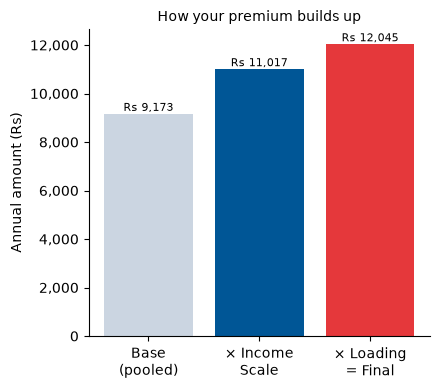

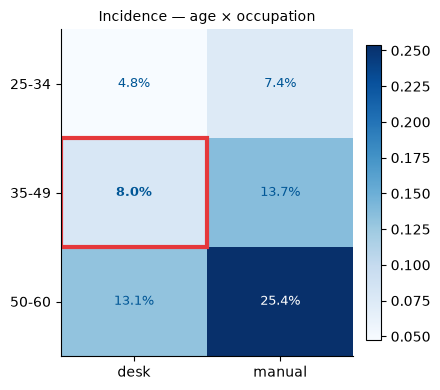

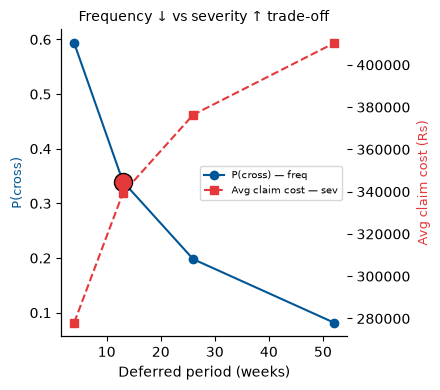

In [10]:
def show_ip_charts(quote):
    """Renders all 3 IP charts for a given quote dict, side by side."""
    fig1 = render_premium_waterfall(quote)
    fig2 = render_incidence_heatmap(
        ip_base_table, AGE_BAND_LABELS, OCCUPATION_CLASSES,
        highlight_age_band=age_band(quote['age']), highlight_occupation=quote['occupation'],
    )
    fig3 = render_deferred_tradeoff(ip_deferred_period_table, highlight_weeks=quote['deferred_weeks'])
    plt.show()


show_ip_charts(example)

## 3. PMI Tools — Frequency × Severity, No Expense/Profit Loading

A simpler product than IP: no multi-state model, no deferred period, no experience rating. Just three governed pieces — frequency (by age band), severity (by sum-insured band), and an NCB discount ladder — multiplied together into a **pure risk premium**. Nothing is added for expenses, contingency, or profit; see `pmi_policy_assumptions.md` for why, and for how this deliberately differs from the fuller PMI worked example used elsewhere in the seminar.

In [11]:
PMI_AGE_BAND_LABELS = {0: '18-35', 1: '36-50', 2: '51-65'}
PMI_AGE_BAND_EDGES = [18, 36, 51, 66]
PMI_SI_BAND_VALUES = {'3L': 300000, '5L': 500000, '10L': 1000000, '20L': 2000000, '50L': 5000000}
PMI_NCB_TIERS = [0, 10, 20, 30, 40, 50]

VALID_PMI_SI_LABELS = list(PMI_SI_BAND_VALUES)


def pmi_age_band(age):
    """Bands age into the three PMI rating groups. Clamps at either end - PMI is priced for
    any adult age, no invented band possible."""
    for i, (lo, hi) in enumerate(zip(PMI_AGE_BAND_EDGES[:-1], PMI_AGE_BAND_EDGES[1:])):
        if lo <= age < hi:
            return i
    return len(PMI_AGE_BAND_EDGES) - 2


def check_pmi_sum_insured_exists(sum_insured):
    """GUARDRAIL — PMI is sold at fixed sum-insured tiers, not any arbitrary amount. Refuses
    to price a sum insured that isn't one of the standard options."""
    matches = [label for label, val in PMI_SI_BAND_VALUES.items() if val == sum_insured]
    exists = len(matches) == 1
    return {'exists': exists, 'requested': sum_insured, 'resolved_label': matches[0] if exists else None,
            'valid_options': PMI_SI_BAND_VALUES}


def check_pmi_ncb_exists(ncb_tier):
    """GUARDRAIL — refuses to price an NCB tier outside the standard discount ladder."""
    try:
        tier = int(ncb_tier)
        exists = tier in PMI_NCB_TIERS
    except (TypeError, ValueError):
        tier, exists = None, False
    return {'exists': exists, 'requested': ncb_tier, 'valid_tiers': PMI_NCB_TIERS}


def explain_pmi_frequency(age):
    """Explains PMI claim frequency using ONLY numbers from pmi_frequency_table."""
    a_band = pmi_age_band(age)
    row = pmi_frequency_table.iloc[a_band]
    return (f"FREQUENCY — for age band {row['age_band']}: {row['frequency']:.2%} annual "
            f"probability of at least one claim, estimated from {int(row['n_policies']):,} "
            f"policies in this band.")


def explain_pmi_severity(sum_insured):
    """Explains PMI claim severity using ONLY numbers from pmi_severity_table. No invention
    for a non-standard sum insured."""
    check = check_pmi_sum_insured_exists(sum_insured)
    if not check['exists']:
        options = ", ".join(f"{lbl} (Rs {val:,})" for lbl, val in PMI_SI_BAND_VALUES.items())
        return (f"I can't price a sum insured of Rs {sum_insured:,} - the standard tiers are "
                f"{options}. I won't invent a severity figure for anything outside that ladder.")
    row = pmi_severity_table[pmi_severity_table['sum_insured_band'] == check['resolved_label']].iloc[0]
    return (f"SEVERITY — for sum insured {check['resolved_label']}: average claim of "
            f"Rs {row['avg_severity']:,.0f}, estimated from {int(row['n_claims']):,} claims "
            f"in this band.")


def explain_pmi_ncb(ncb_tier):
    """Explains the NCB discount using ONLY numbers from pmi_ncb_table. No invention for a
    non-standard tier."""
    check = check_pmi_ncb_exists(ncb_tier)
    if not check['exists']:
        return (f"I can't apply an NCB tier of {ncb_tier}% - the standard ladder is "
                f"{PMI_NCB_TIERS}. I won't invent a discount for anything outside that ladder.")
    tier = int(ncb_tier)
    row = pmi_ncb_table[pmi_ncb_table['ncb_tier'] == tier].iloc[0]
    return (f"NCB — at {tier}% no-claim bonus tier, a {(1 - row['discount_factor']):.0%} "
            f"discount is applied to the premium (a governance rule, not estimated from this "
            f"year's claims data - see pmi_policy_assumptions.md).")

In [12]:
def calculate_pmi_premium(age, sum_insured, ncb_tier=0):
    """Combines PMI Tool 1 (frequency by age band), Tool 2 (severity by sum-insured band), and
    Tool 3 (NCB discount ladder) into a pure risk premium. NO expense or profit loading -
    see pmi_policy_assumptions.md for why."""
    si_check = check_pmi_sum_insured_exists(sum_insured)
    if not si_check['exists']:
        raise ValueError(f"Cannot price sum insured Rs {sum_insured:,} - not one of "
                          f"the standard tiers {list(PMI_SI_BAND_VALUES.values())}.")
    si_label = si_check['resolved_label']

    ncb_check = check_pmi_ncb_exists(ncb_tier)
    if not ncb_check['exists']:
        raise ValueError(f"Cannot apply NCB tier {ncb_tier}% - not one of {PMI_NCB_TIERS}.")
    tier = int(ncb_tier)

    a_band = pmi_age_band(age)
    frequency = float(pmi_frequency_table.iloc[a_band]['frequency'])
    severity = float(pmi_severity_table[pmi_severity_table['sum_insured_band'] == si_label].iloc[0]['avg_severity'])
    ncb_discount = float(pmi_ncb_table[pmi_ncb_table['ncb_tier'] == tier].iloc[0]['discount_factor'])

    pure_premium = frequency * severity
    final_premium = pure_premium * ncb_discount

    return {
        'age': age,
        'age_band': PMI_AGE_BAND_LABELS[a_band],
        'sum_insured': sum_insured,
        'sum_insured_band': si_label,
        'ncb_tier': tier,
        'frequency': round(frequency, 4),
        'severity': round(severity, 0),
        'pure_premium': round(pure_premium, 0),
        'ncb_discount_factor': ncb_discount,
        'final_annual_premium': round(final_premium, 0),
    }


pmi_example = calculate_pmi_premium(age=52, sum_insured=1000000, ncb_tier=30)
for k, v in pmi_example.items():
    print(f"{k:22s}: {v}")
print()
print(explain_pmi_frequency(52))
print(explain_pmi_severity(1000000))
print(explain_pmi_ncb(30))

age                   : 52
age_band              : 51-65
sum_insured           : 1000000
sum_insured_band      : 10L
ncb_tier              : 30
frequency             : 0.0932
severity              : 87778.0
pure_premium          : 8181.0
ncb_discount_factor   : 0.85
final_annual_premium  : 6954.0

FREQUENCY — for age band 51-65: 9.32% annual probability of at least one claim, estimated from 6,145 policies in this band.
SEVERITY — for sum insured 10L: average claim of Rs 87,778, estimated from 431 claims in this band.
NCB — at 30% no-claim bonus tier, a 15% discount is applied to the premium (a governance rule, not estimated from this year's claims data - see pmi_policy_assumptions.md).


## 4. RAG — Policy Assumption Documents

Same lightweight TF-IDF retrieval technique as the earlier mini-RAG pattern in this series — no vector database, no embeddings API call, just `scikit-learn`. What's different is *what* it searches: two real markdown documents (`ip_policy_assumptions.md`, `pmi_policy_assumptions.md`) capturing every modelling assumption behind each product, chunked by section, so the team can answer "what does this coverage assume" questions with a citable source instead of the model's own general knowledge.

This keeps a clean separation that matters for trust: **numbers come from the pricing tools, policy/assumption answers come from these documents** — never blended, never guessed.

In [13]:
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def load_policy_chunks(filepaths):
    """Splits each markdown file into its ## sections, so retrieval returns one coherent
    topic at a time rather than a whole document or a single sentence."""
    chunks = {}
    for path in filepaths:
        text = Path(path).read_text(encoding='utf-8')
        doc_id = Path(path).stem
        sections = text.split('\n## ')
        for i, section in enumerate(sections):
            if i > 0:
                section = '## ' + section
            section = section.strip()
            if not section:
                continue
            heading = section.splitlines()[0].lstrip('#').strip()
            chunk_id = f"{doc_id} :: {heading[:60]}"
            chunks[chunk_id] = section
    return chunks


POLICY_CHUNKS = load_policy_chunks([fetch_if_missing('ip_policy_assumptions.md'),
                                    fetch_if_missing('pmi_policy_assumptions.md')])
_vec = TfidfVectorizer().fit(POLICY_CHUNKS.values())
_mat = _vec.transform(POLICY_CHUNKS.values())
_chunk_keys = list(POLICY_CHUNKS)

print(f"Loaded {len(POLICY_CHUNKS)} policy-document chunks:")
for k in _chunk_keys:
    print(f"  - {k}")

Loaded 16 policy-document chunks:
  - ip_policy_assumptions :: ABC Health — Income Protection (IP): Policy & Pricing Assump
  - ip_policy_assumptions :: What the coverage does
  - ip_policy_assumptions :: States a policyholder can be in
  - ip_policy_assumptions :: Deferred period
  - ip_policy_assumptions :: Premium — how it's charged
  - ip_policy_assumptions :: Rating factors — what changes the premium, and how
  - ip_policy_assumptions :: What is explicitly *not* modelled in this teaching version
  - ip_policy_assumptions :: Data basis
  - pmi_policy_assumptions :: ABC Health — Private Medical Insurance (PMI): Policy & Prici
  - pmi_policy_assumptions :: What the coverage does
  - pmi_policy_assumptions :: Pricing structure — frequency × severity
  - pmi_policy_assumptions :: Portfolio reference figures
  - pmi_policy_assumptions :: Why frequency and severity are estimated differently from NC
  - pmi_policy_assumptions :: What is explicitly *not* modelled in this teaching version
 

In [14]:
def search_policy_docs(query: str) -> dict:
    """Search ABC Health's policy assumption documents for IP and PMI. Returns the single most
    relevant passage and its source chunk id - always cite the source in any answer built from
    this result."""
    sims = cosine_similarity(_vec.transform([query]), _mat)[0]
    i = int(sims.argmax())
    return {
        'source': _chunk_keys[i],
        'passage': POLICY_CHUNKS[_chunk_keys[i]],
        'relevance_score': round(float(sims[i]), 3),
    }


result = search_policy_docs("does PMI include expense and profit loading")
print(f"Source: {result['source']} (score={result['relevance_score']})")
print(result['passage'][:400])

Source: pmi_policy_assumptions :: Relationship to the fuller PMI worked example used elsewhere (score=0.215)
## Relationship to the fuller PMI worked example used elsewhere in this seminar

Other materials in this seminar reference a fully-loaded worked example (a 52-year-old, ₹10L sum insured, Family Floater, 30% NCB, resolving to a specific final premium). That example **includes** expense and profit loading and plan-type rating, which this simplified notebook-05 tool deliberately excludes. **Do not ex


## 5. Two Specialist Agents

In [15]:
IP_SYSTEM_PROMPT = """You are the ABC Health IP Pricing Logic Explainer.

WHO YOU ARE, AND WHO YOU ARE NOT: you draft Income Protection premium explanations for the pricing actuary
Nair, the lead pricing actuary, who reviews and signs everything you produce. You are not
the pricing actuary. Never write in anyone's name and never sign anything. You draft; a qualified human signs.

WHAT EACH TOOL MEANS - READ CAREFULLY, THESE ARE NOT INTERCHANGEABLE:

- Tool 1 (age x occupation base rate, via calculate_premium / explain_transition('healthy') /
  explain_occupation): the annual probability that a HEALTHY person in this age/occupation
  group falls sick at all. This is FREQUENCY OF FALLING SICK. It is NOT the probability of
  claiming - most sickness spells never become a paid claim.

- Tool 2 (deferred-period table, via explain_deferred_option): given that a sickness spell has
  occurred, two things - (a) FREQUENCY: what fraction of those spells actually survive the
  deferred period and cross into a paid claim, and (b) SEVERITY: how long the claim runs and
  what it costs, for the deferred period the policyholder actually chose.

- Income scaling (inside calculate_premium only, not a separate tool): Tool 1 and Tool 2's
  numbers are pooled across the whole portfolio. The policyholder's actual income multiplies
  the pooled severity figure up or down to their own income level. This is why
  calculate_premium's output has a field called avg_claim_cost_for_your_income, not
  avg_claim_cost - always use the "for_your_income" figure when discussing THIS policyholder's
  expected claim cost, never the pooled Tool 2 table value directly.

- Tool 3 (episode-based loading, via explain_loading): a personal multiplier on top of
  everything above, based on the policyholder's own prior-episode count. It blends both a
  higher chance of a spell reaching claiming AND a longer claim once it does for people with
  more prior episodes - do not describe it as a pure frequency or pure severity number, it is
  both blended into one factor.

CRITICAL PRECISION RULE - this is a distinct failure mode from inventing numbers, and it
matters just as much:
- NEVER say Tool 1's incidence rate is "the probability of claiming," "the chance you'll need
  a claim," or similar. It is only the probability of FALLING SICK.
- The actual probability of reaching a paid claim is Tool 1's incidence x Tool 2's crossing
  probability, multiplied together - state this explicitly as two separate factors being
  combined, don't collapse them into one figure or badge either one with the other's meaning.
- Citing a real, correctly-sourced number with an incorrect description of what it represents
  is just as much a failure as inventing a number outright. Check every sentence you write
  against what the underlying tool actually measures before saying it.

RULES:
1. Never state a transition rate, loading factor, occupation effect, or deferred-period effect
   unless it came from a tool call.
2. If asked about a factor, category, or option that isn't in the tables (an occupation outside
   desk/manual, a non-standard deferred period, a smoker/non-smoker loading, an episode band
   beyond what's credible), say so plainly and refuse to invent a number.
3. Always explain premiums by naming each contributing piece separately and correctly: Tool 1's
   frequency-of-falling-sick, Tool 2's frequency-of-claiming and severity for the chosen
   deferred period, the income scaling applied to that severity, and Tool 3's loading for prior
   sickness history - never collapse these into one opaque number.
4. NEVER use the "$" symbol for currency, even once. Write "INR" or "Rs" instead - some chat
   interfaces render "$...$" as a math equation, silently breaking formatting.
"""

try:
    from agno.agent import Agent
    from agno.models.google import Gemini

    ip_agent = Agent(
        name="IP Pricing Agent",
        role="Prices Income Protection cover and explains the premium build-up",
        model=Gemini(id="gemini-3.5-flash-lite"),
        tools=[calculate_premium, explain_transition, explain_loading, explain_occupation,
               explain_deferred_option, check_state_exists, check_episode_band_exists,
               check_occupation_exists, check_deferred_option_exists],
        instructions=IP_SYSTEM_PROMPT,
        markdown=True,
    )
    print("IP Pricing Agent ready.")
except Exception as e:
    print(f"IP Pricing Agent not instantiated in this environment ({type(e).__name__}: {e}).")
    print("Tool functions above are fully verified standalone - wire in a live GOOGLE_API_KEY to run it.")

IP Pricing Agent ready.


In [16]:
PMI_SYSTEM_PROMPT = """You are the ABC Health PMI Pricing Logic Explainer.

WHO YOU ARE, AND WHO YOU ARE NOT: you draft Private Medical Insurance premium explanations for
the pricing team. The Chief Pricing Actuary is the person who signs them. You are not
any named actuary. Never write in anyone's name, and never present
your output as a signed actuarial opinion. You draft; a human signs.

WHAT EACH TOOL MEANS:
- Frequency (by age band, via explain_pmi_frequency): the annual probability of at least one
  claim. Unlike Income Protection, there is no separate "falling sick vs actually claiming"
  distinction for PMI - frequency here directly IS the probability of a claim.
- Severity (by sum-insured band, via explain_pmi_severity): the average cost of a claim, given
  one happens.
- NCB discount (via explain_pmi_ncb): a loyalty discount ladder for consecutive claim-free
  years - a governance/product-design rule, not something estimated from this year's claims
  data. Do not describe it as if it were empirically fitted.

CRITICAL: calculate_pmi_premium prices PURE RISK PREMIUM ONLY. No expense loading, no profit
margin, no contingency margin is included. If asked why this number looks lower than a
fully-loaded quote used elsewhere, say so explicitly - it is a deliberate simplification of
this teaching tool, not an error or an inconsistency.

RULES:
1. Never state a frequency, severity, or NCB discount unless it came from a tool call.
2. If asked about a sum insured or NCB tier outside the standard ladders, say so plainly and
   refuse to invent a number - PMI is sold at fixed sum-insured tiers, not arbitrary amounts.
3. Always name each contributing piece separately: frequency x severity = pure premium, then
   x NCB discount = final premium. Never collapse into one opaque number.
4. NEVER use the "$" symbol for currency, even once. Write "INR" or "Rs" instead.
"""

try:
    from agno.agent import Agent
    from agno.models.google import Gemini

    pmi_agent = Agent(
        name="PMI Pricing Agent",
        role="Prices PMI (hospitalisation) cover and explains the premium build-up",
        model=Gemini(id="gemini-3.5-flash-lite"),
        tools=[calculate_pmi_premium, explain_pmi_frequency, explain_pmi_severity, explain_pmi_ncb,
               check_pmi_sum_insured_exists, check_pmi_ncb_exists],
        instructions=PMI_SYSTEM_PROMPT,
        markdown=True,
    )
    print("PMI Pricing Agent ready.")
except Exception as e:
    print(f"PMI Pricing Agent not instantiated in this environment ({type(e).__name__}: {e}).")
    print("Tool functions above are fully verified standalone - wire in a live GOOGLE_API_KEY to run it.")

PMI Pricing Agent ready.


## 6. The Team — Route Mode

`TeamMode.route` makes the leader act as a traffic director: inspect the query, then either hand it to whichever specialist agent fits, or — since the leader keeps its own tools even in route mode — answer directly using `search_policy_docs` for questions about assumptions rather than a specific quote.

In [17]:
TEAM_INSTRUCTIONS = """You are the ABC Health Pricing Desk, coordinating two specialist
pricing agents and your own policy-document search tool.

ROUTING:
- Route to the IP Pricing Agent for anything about Income Protection: sickness, deferred
  periods, income replacement, prior sickness episodes.
- Route to the PMI Pricing Agent for anything about PMI: hospitalisation, sum insured, NCB,
  PMI premiums.
- For questions about POLICY ASSUMPTIONS or COVERAGE DEFINITIONS rather than a specific
  premium number (e.g. "what deferred periods are offered", "does PMI include expense
  loading", "what isn't modelled in this tool"), answer directly YOURSELF using
  search_policy_docs - do not route these to either specialist agent, since they're about
  product design, not a calculation.

NEVER invent a number yourself, in any capacity. If search_policy_docs doesn't have the
answer, say so plainly rather than guessing. If a query needs both a PMI number AND an IP
number, route to each agent in turn and combine their answers - do not answer for them.
"""

try:
    from agno.team import Team, TeamMode
    from agno.models.google import Gemini

    pricing_team = Team(
        name="ABC Health Pricing Desk",
        mode=TeamMode.route,
        members=[ip_agent, pmi_agent],
        model=Gemini(id="gemini-3.5-flash-lite"),
        tools=[search_policy_docs],
        instructions=TEAM_INSTRUCTIONS,
        markdown=True,
    )
    print("ABC Health Pricing Desk (Team, route mode) ready.")
except Exception as e:
    print(f"Team not instantiated in this environment ({type(e).__name__}: {e}).")
    print("Both agents' tool functions are fully verified standalone - wire in a live GOOGLE_API_KEY to run the team.")

ABC Health Pricing Desk (Team, route mode) ready.


## 7. Live Demo — Three Queries, Three Different Paths

1. An IP question — should route to the IP Pricing Agent.
2. A PMI question — should route to the PMI Pricing Agent.
3. A policy/assumptions question — should be answered directly by the team leader, from `search_policy_docs`, not routed to either specialist.

In [18]:
ip_query = ("I'm 45, my monthly income is Rs 80,000, I work a desk job, and this is my "
            "1st sickness episode. What's my Income Protection premium, with a 13-week "
            "deferred period?")

try:
    pricing_team.print_response(ip_query, stream=True, show_full_reasoning=False)
except Exception:
    print("Team unavailable offline - showing the equivalent direct tool trace instead:\n")
    result = calculate_premium(age=45, monthly_income=80000, prior_episodes=1, occupation='desk')
    for k, v in result.items():
        print(f"  {k}: {v}")

Output()

In [19]:
pmi_query = "I'm 52, sum insured Rs 10,00,000, and I have a 30% NCB. What's my PMI premium?"

try:
    pricing_team.print_response(pmi_query, stream=True, show_full_reasoning=False)
except Exception:
    print("Team unavailable offline - showing the equivalent direct tool trace instead:\n")
    result = calculate_pmi_premium(age=52, sum_insured=1000000, ncb_tier=30)
    for k, v in result.items():
        print(f"  {k}: {v}")

Output()

In [20]:
policy_query = "Does the IP product cover a death benefit? And does PMI include expenses in the premium?"

try:
    pricing_team.print_response(policy_query, stream=True, show_full_reasoning=False)
except Exception:
    print("Team unavailable offline - showing the equivalent direct RAG trace instead:\n")
    for q in ["death benefit income protection", "PMI expenses profit loading"]:
        r = search_policy_docs(q)
        print(f"query: {q!r} -> source: {r['source']} (score={r['relevance_score']})")
        print(r['passage'][:300], "\n")

Output()

### Show the IP charts for the first query too

Since the agent's text response doesn't carry an image, the visual companion to "why is my premium what it is" is rendered separately here, the same way notebook 04 pairs its agent narration with the dashboard.

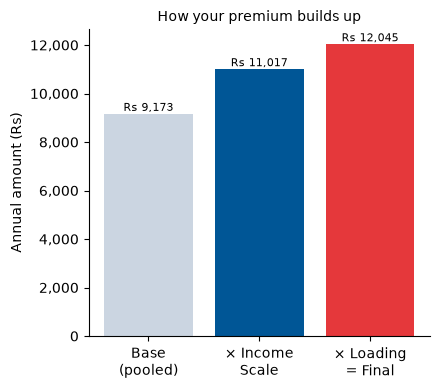

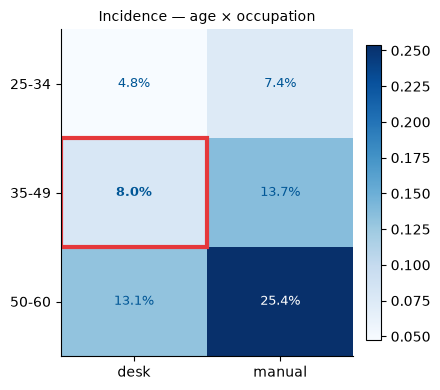

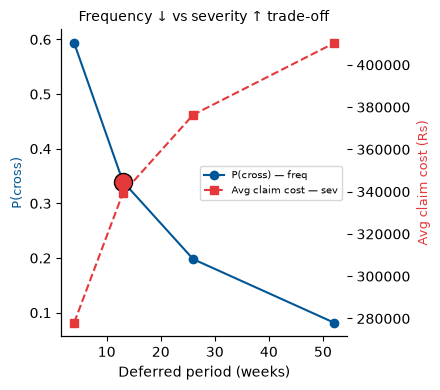

In [21]:
ip_quote_for_charts = calculate_premium(age=45, monthly_income=80000, prior_episodes=1, occupation='desk')
show_ip_charts(ip_quote_for_charts)

## 8. Exercises

1. **Add a third specialist** — sketch (in words, or in code if you have time) what a Critical Illness pricing agent would need: which tool(s) from notebook 03's `incidence_rate` function would it reuse, and what routing instruction would the team leader need to tell IP, PMI, and CI apart?
2. **Broaden the RAG** — add a third markdown document (e.g. `claims_process.md`, describing how a claim is actually lodged and paid) and confirm `search_policy_docs` retrieves from it correctly for a claims-process question.
3. **Test the router's judgment** — ask the team a deliberately ambiguous query that touches both products (e.g. "I have both an IP and a PMI policy, what's my total annual premium across both?") and read the trace: does it call both agents, or does it need a clearer instruction to do so?
4. **Add a PMI guardrail for plan type** — `pmi_policy_assumptions.md` notes that plan type (Individual vs. Family Floater) isn't modelled. Add it: a new rating factor in `calculate_pmi_premium`, a guardrail, and an update to the policy document so the RAG reflects the change too.
5. **Compare the two personas** — the lead pricing actuary (IP) and the Chief Pricing Actuary (PMI) have different system prompts written for different product mechanics. What's the *minimum* set of rules every pricing agent in this team should share, regardless of product? Refactor both prompts to pull that shared core into one constant both agents import.